In [ ]:
install.packages('forecast')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘fracdiff’, ‘lmtest’, ‘Rcpp’, ‘timeDate’, ‘tseries’, ‘urca’, ‘zoo’, ‘RcppArmadillo’




In [ ]:
install.packages('tseries')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(dplyr)
library(forecast)
library(tseries)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [ ]:
data = read.csv("/content/currency_exchange_rates_02-01-1995_-_02-05-2018.csv")
data1 = select(data,'Date','Singapore.Dollar','U.S..Dollar')

[link text](https://)
Remove the NA in singapore dollars

In [ ]:
data_clean = data1[is.na(data1$Singapore.Dollar) == FALSE,]

 Convert 'Date' column to actual date format

In [ ]:
data_clean$Date = as.Date(data_clean$Date)
ts_data = ts(data_clean$Singapore.Dollar)

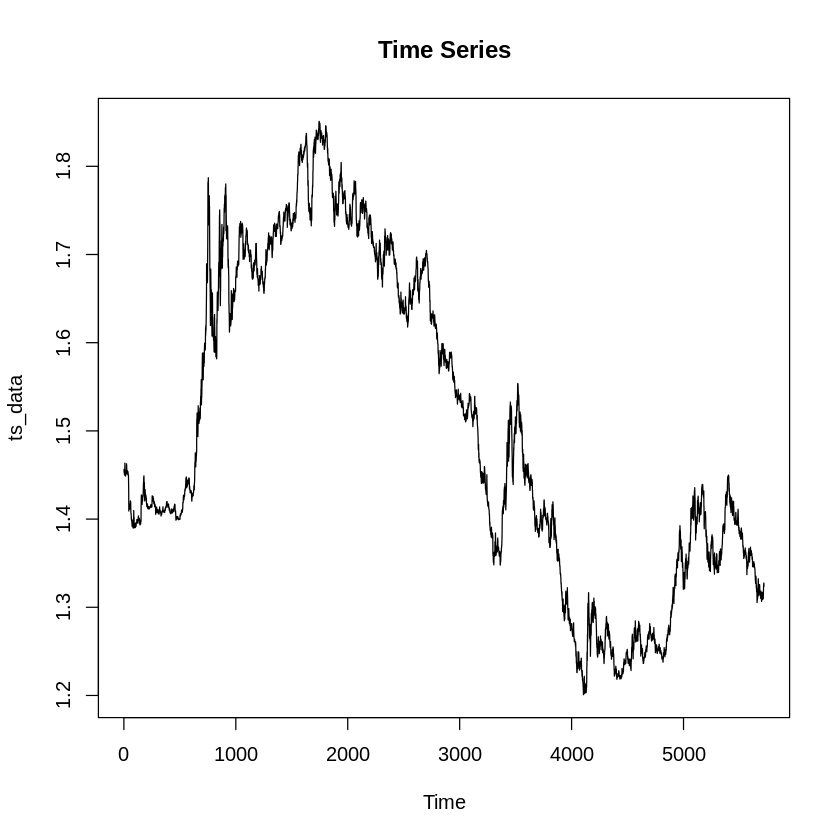

In [ ]:
plot(ts_data, main = "Time Series")

Test stationality of original data (Not stationary due p-value >0.05)

In [ ]:
adf_test = adf.test(ts_data)
print(adf_test)


	Augmented Dickey-Fuller Test

data:  ts_data
Dickey-Fuller = -1.9591, Lag order = 17, p-value = 0.5957
alternative hypothesis: stationary



function (x, lag.max = NULL, type = c("correlation", "covariance", 
    "partial"), plot = TRUE, na.action = na.fail, demean = TRUE, 
    ...) 
{
    type <- match.arg(type)
    if (type == "partial") {
        m <- match.call()
        m[[1L]] <- quote(stats::pacf)
        m$type <- NULL
        return(eval(m, parent.frame()))
    }
    series <- deparse1(substitute(x))
    x <- na.action(as.ts(x))
    x.freq <- frequency(x)
    x <- as.matrix(x)
    if (!is.numeric(x)) 
        stop("'x' must be numeric")
    sampleT <- as.integer(nrow(x))
    nser <- as.integer(ncol(x))
    if (is.na(sampleT) || is.na(nser)) 
        stop("'sampleT' and 'nser' must be integer")
    if (is.null(lag.max)) 
        lag.max <- floor(10 * (log10(sampleT) - log10(nser)))
    lag.max <- as.integer(min(lag.max, sampleT - 1L))
    if (is.na(lag.max) || lag.max < 0) 
        stop("'lag.max' must be at least 0")
    if (demean) 
        x <- sweep(x, 2, colMeans(x, na.rm = TRUE), check.margin = FALSE)
    lag <- matrix(1, nser, nser)
    lag[lower.tri(lag)] <- -1
    acf <- .Call(C_acf, x, lag.max, type == "correlation")
    lag <- outer(0:lag.max, lag/x.freq)
    acf.out <- structure(list(acf = acf, type = type, n.used = sampleT, 
        lag = lag, series = series, snames = colnames(x)), class = "acf")
    if (plot) {
        plot.acf(acf.out, ...)
        invisible(acf.out)
    }
    else acf.out
}
<bytecode: 0x58799f439328>
<environment: namespace:stats>

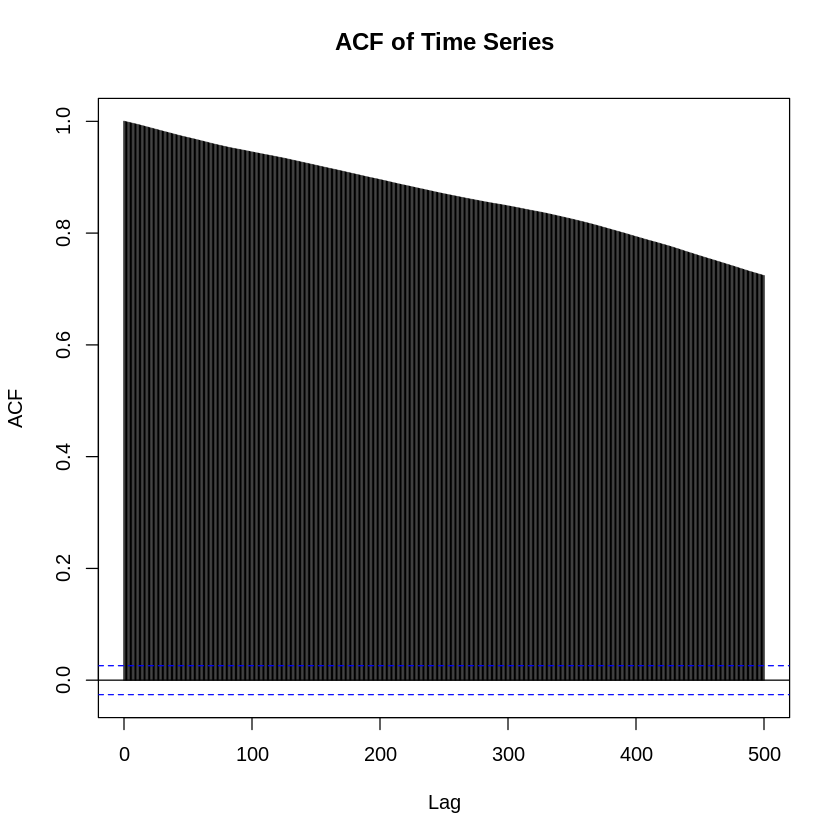

function (x, lag.max, plot, na.action, ...) 
UseMethod("pacf")
<bytecode: 0x587996af16a0>
<environment: namespace:stats>

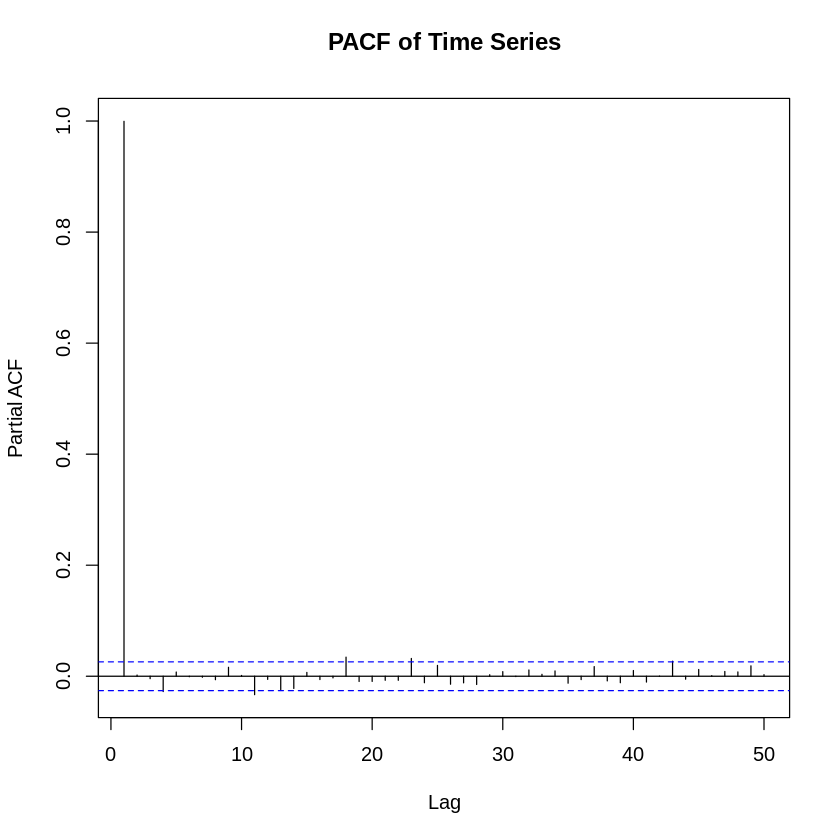

In [ ]:
acf(ts_data, main = "ACF of Time Series", lag.max = 500)
acf

pacf(ts_data, main = "PACF of Time Series", lag.max = 50)
pacf

Diff to make data stationary

In [ ]:
ts_data_diff = diff(ts_data)

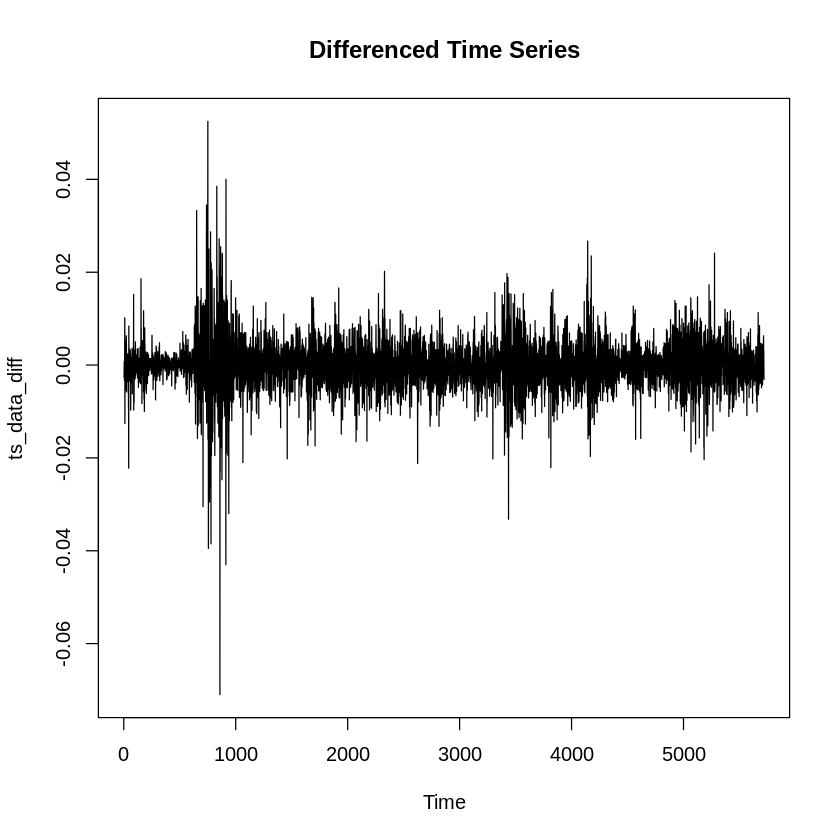

In [ ]:
plot(ts_data_diff, main = "Differenced Time Series")

In [ ]:
adf_test1 = adf.test(ts_data_diff)
print(adf_test1)

Warning message in adf.test(ts_data_diff):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  ts_data_diff
Dickey-Fuller = -17.242, Lag order = 17, p-value = 0.01
alternative hypothesis: stationary



Plot ACF and PACF



---



function (x, lag.max = NULL, type = c("correlation", "covariance", 
    "partial"), plot = TRUE, na.action = na.fail, demean = TRUE, 
    ...) 
{
    type <- match.arg(type)
    if (type == "partial") {
        m <- match.call()
        m[[1L]] <- quote(stats::pacf)
        m$type <- NULL
        return(eval(m, parent.frame()))
    }
    series <- deparse1(substitute(x))
    x <- na.action(as.ts(x))
    x.freq <- frequency(x)
    x <- as.matrix(x)
    if (!is.numeric(x)) 
        stop("'x' must be numeric")
    sampleT <- as.integer(nrow(x))
    nser <- as.integer(ncol(x))
    if (is.na(sampleT) || is.na(nser)) 
        stop("'sampleT' and 'nser' must be integer")
    if (is.null(lag.max)) 
        lag.max <- floor(10 * (log10(sampleT) - log10(nser)))
    lag.max <- as.integer(min(lag.max, sampleT - 1L))
    if (is.na(lag.max) || lag.max < 0) 
        stop("'lag.max' must be at least 0")
    if (demean) 
        x <- sweep(x, 2, colMeans(x, na.rm = TRUE), check.margin = FALSE)
    lag <- matrix(1, nser, nser)
    lag[lower.tri(lag)] <- -1
    acf <- .Call(C_acf, x, lag.max, type == "correlation")
    lag <- outer(0:lag.max, lag/x.freq)
    acf.out <- structure(list(acf = acf, type = type, n.used = sampleT, 
        lag = lag, series = series, snames = colnames(x)), class = "acf")
    if (plot) {
        plot.acf(acf.out, ...)
        invisible(acf.out)
    }
    else acf.out
}
<bytecode: 0x58799f439328>
<environment: namespace:stats>

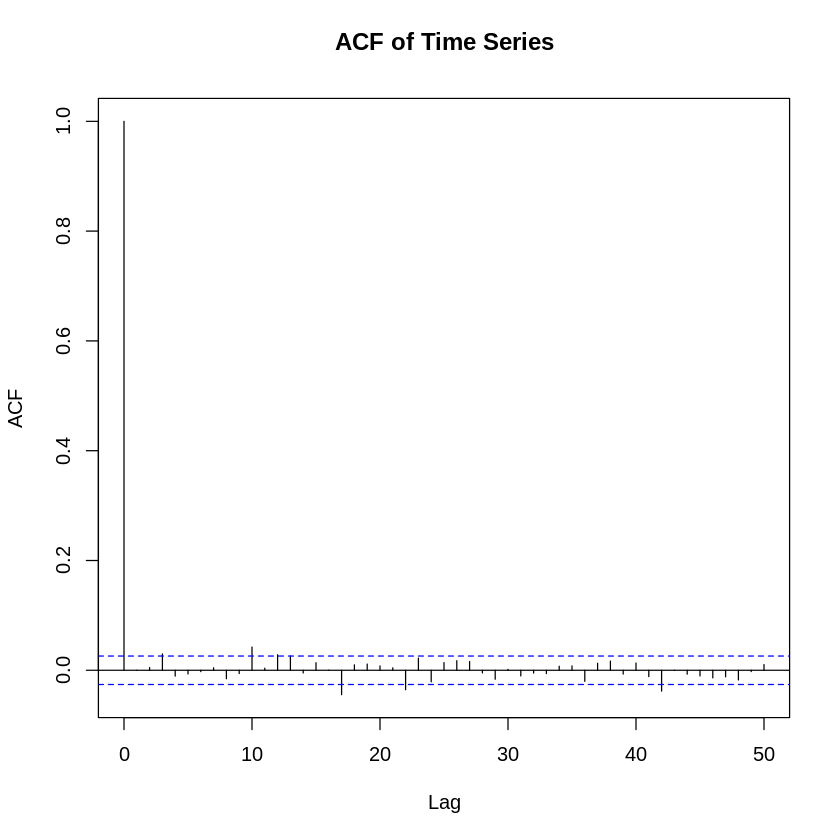

function (x, lag.max, plot, na.action, ...) 
UseMethod("pacf")
<bytecode: 0x587996af16a0>
<environment: namespace:stats>

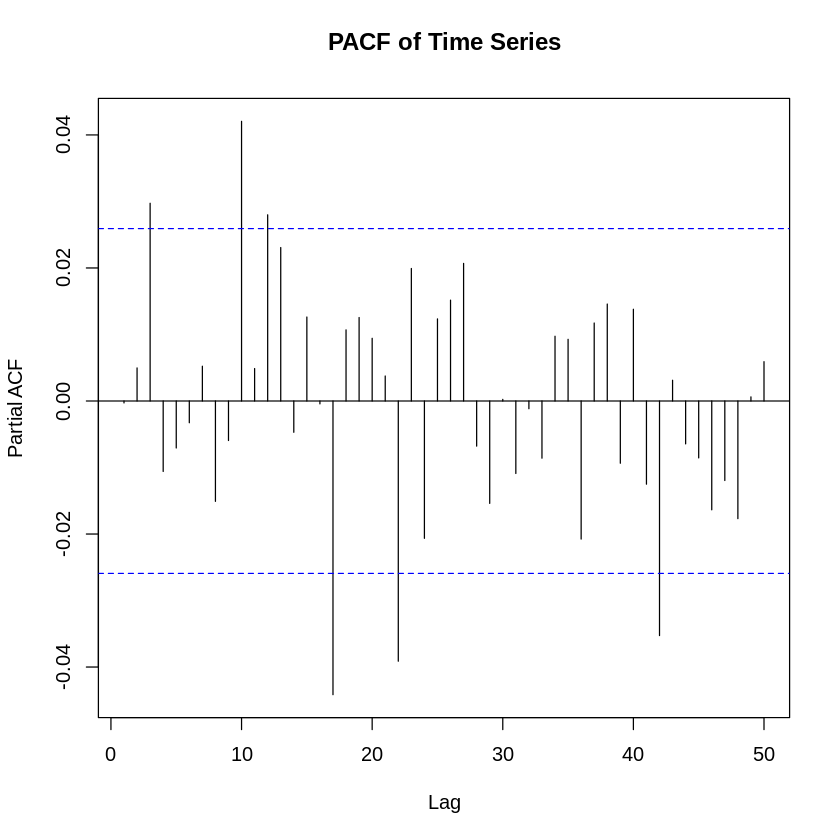

In [ ]:
acf(ts_data_diff, main = "ACF of Time Series", lag.max = 50)
acf

pacf(ts_data_diff, main = "PACF of Time Series", lag.max = 50)
pacf

#ACF cuts off after lag 0 -> MA(0)
#PACF does not cut off

ARIMA using auto ARIMA (differenced TS)

In [ ]:
arima_model <- auto.arima(ts_data_diff)
summary(arima_model)

Series: ts_data_diff 
ARIMA(0,0,0) with zero mean 

sigma^2 = 2.893e-05:  log likelihood = 21764.72
AIC=-43527.45   AICc=-43527.45   BIC=-43520.8

Training set error measures:
                        ME        RMSE         MAE MPE MAPE      MASE
Training set -2.317244e-05 0.005378795 0.003675778 100  100 0.7007167
                      ACF1
Training set -0.0002891236

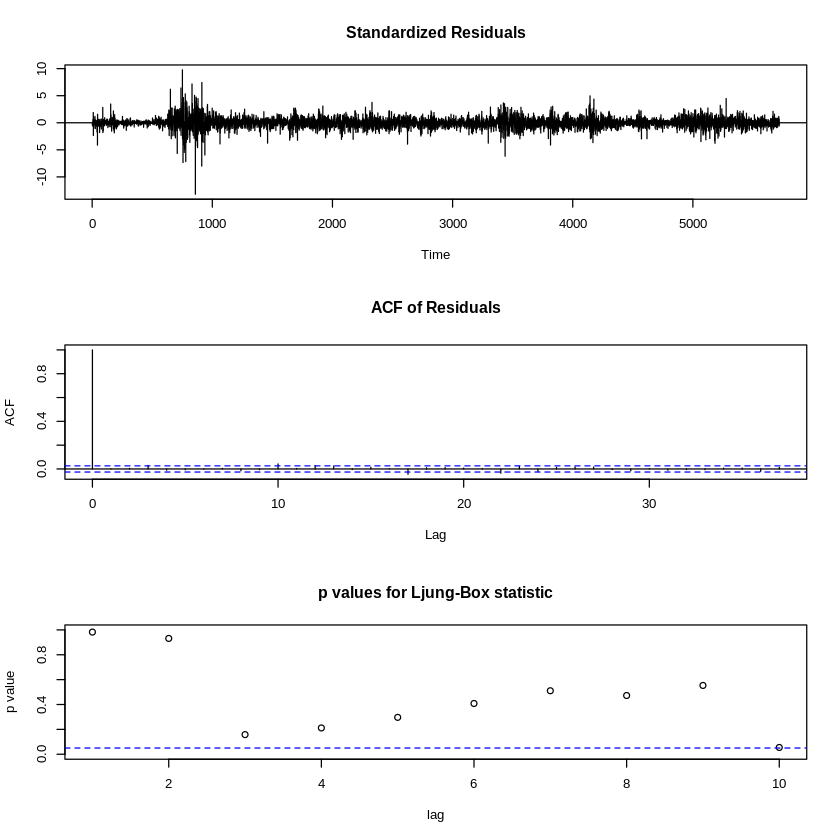

In [ ]:
fit = arima_model
tsdiag(fit)

ARIMA using auto ARIMA (non-stationary TS)

In [ ]:
arima_model1 <- auto.arima(ts_data)
summary(arima_model1)


Series: ts_data 
ARIMA(0,1,0) 

sigma^2 = 2.893e-05:  log likelihood = 21764.72
AIC=-43527.45   AICc=-43527.45   BIC=-43520.8

Training set error measures:
                        ME        RMSE        MAE          MPE      MAPE
Training set -2.291374e-05 0.005378359 0.00367539 -0.002273217 0.2447718
                  MASE          ACF1
Training set 0.9998944 -0.0003121697

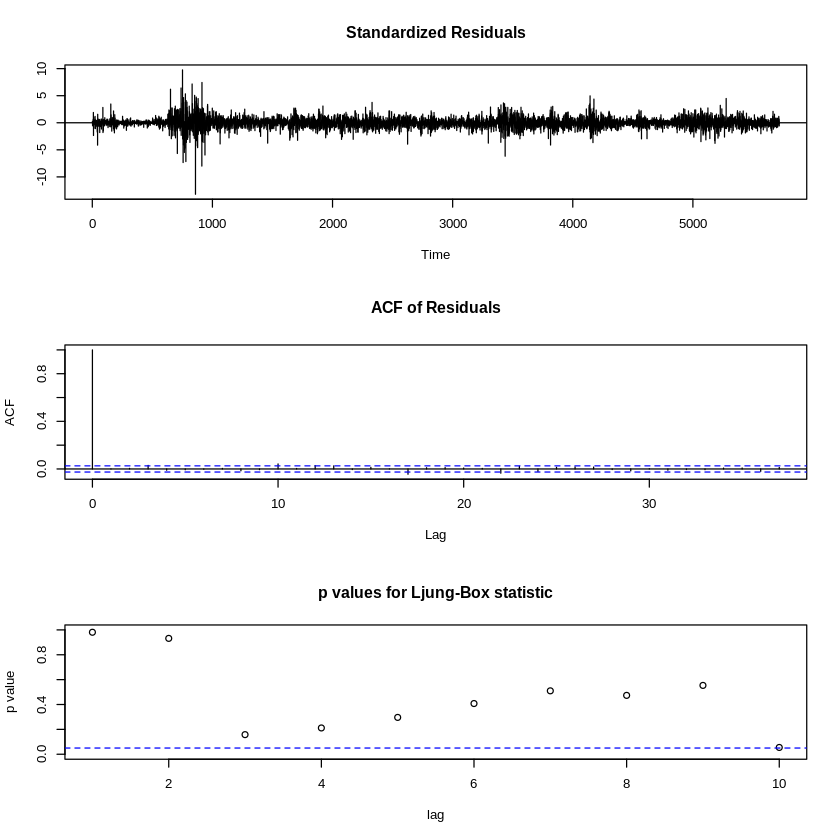

In [ ]:
fit1 = arima_model1
tsdiag(fit1)

ARIMA(0,1,0) Model

In [ ]:
arima_model2 = arima(ts_data, order = c(0,1,0))
summary(arima_model2)


Call:
arima(x = ts_data, order = c(0, 1, 0))


sigma^2 estimated as 2.893e-05:  log likelihood = 21764.72,  aic = -43527.45

Training set error measures:
                        ME        RMSE        MAE          MPE      MAPE
Training set -2.291374e-05 0.005378359 0.00367539 -0.002273217 0.2447718
                  MASE          ACF1
Training set 0.9998944 -0.0003121697

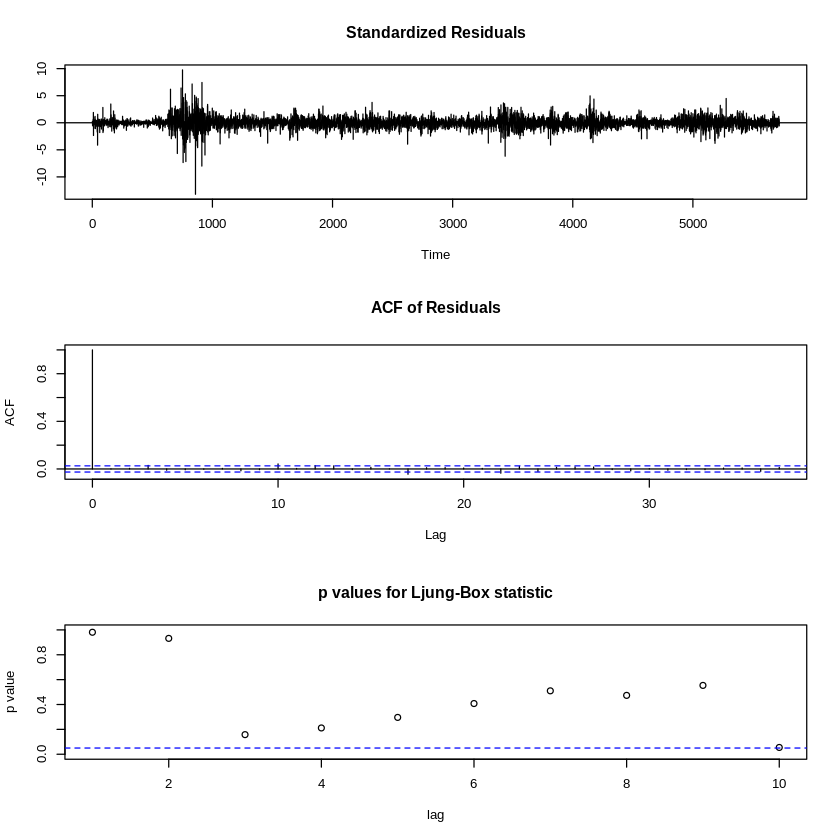

In [ ]:
fit2 = arima_model2
tsdiag(fit2)

# Model is not adequate

Improving model (I will use arima_model2/fit2 since it has the smallest AIC value)

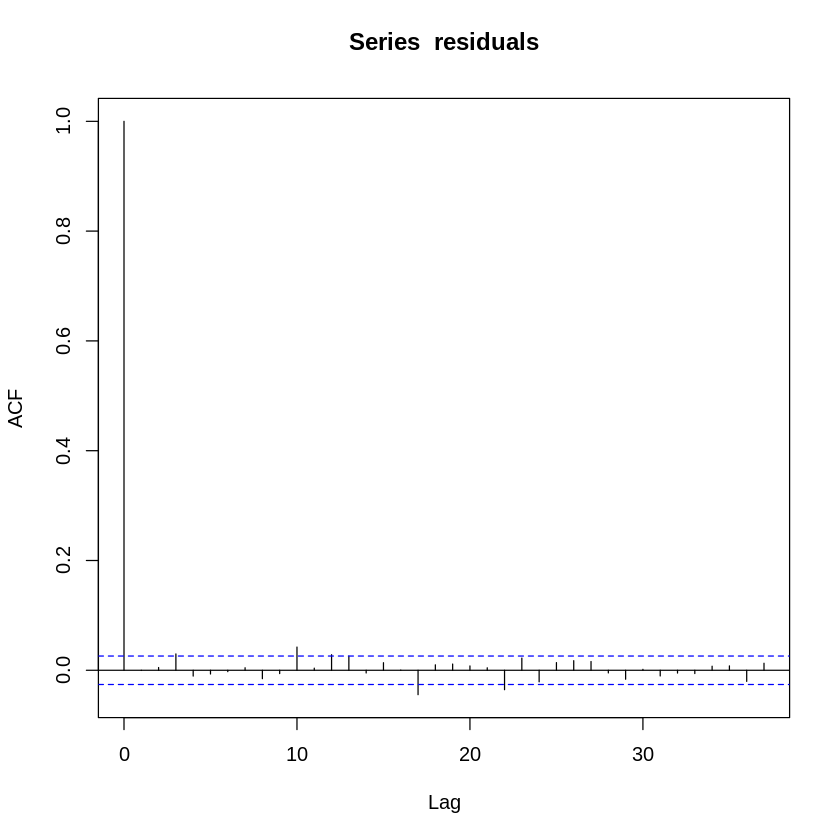

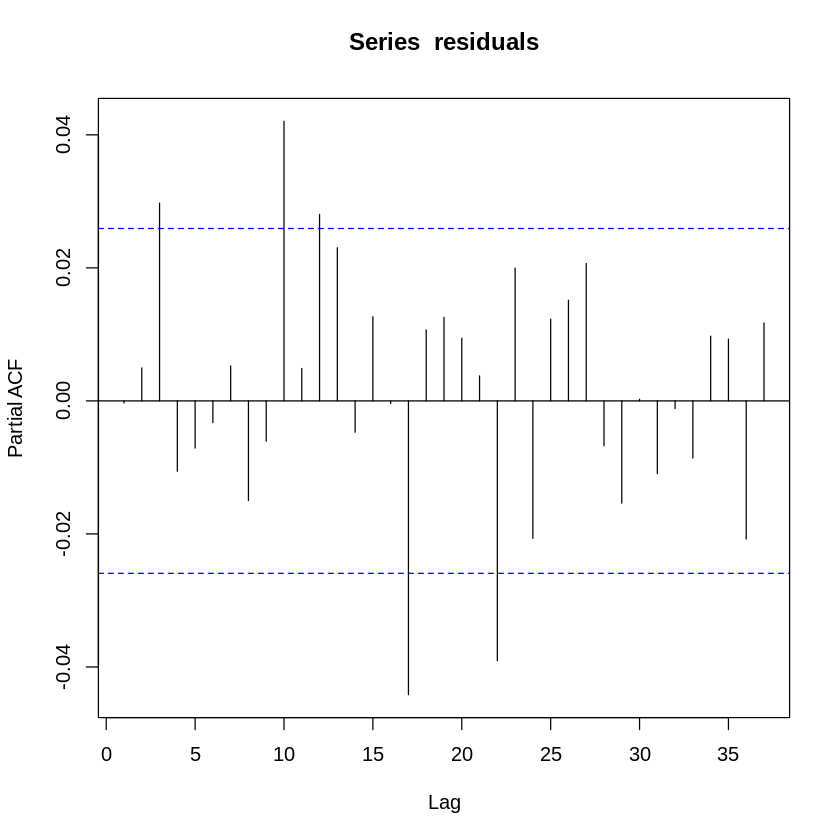

In [ ]:
residuals <- residuals(arima_model2)

# Plot ACF of residuals
acf(residuals)

# Plot PACF of residuals
pacf(residuals)

In [ ]:
# Cuts off after lag 22 for SACF plot -> MA(22)
arima_model_impro = arima(ts_data, order = c(0,1,22))
summary(arima_model_impro)

# AIC value decreased (improved)


Call:
arima(x = ts_data, order = c(0, 1, 22))

Coefficients:
         ma1     ma2     ma3      ma4      ma5      ma6     ma7      ma8
      0.0013  0.0036  0.0298  -0.0074  -0.0063  -0.0009  0.0020  -0.0171
s.e.  0.0132  0.0132  0.0133   0.0133   0.0133   0.0133  0.0133   0.0132
          ma9    ma10    ma11    ma12    ma13     ma14    ma15     ma16
      -0.0054  0.0432  0.0030  0.0299  0.0232  -0.0051  0.0132  -0.0011
s.e.   0.0133  0.0133  0.0133  0.0136  0.0130   0.0134  0.0133   0.0133
         ma17    ma18    ma19    ma20    ma21     ma22
      -0.0446  0.0127  0.0115  0.0049  0.0081  -0.0371
s.e.   0.0131  0.0134  0.0131  0.0132  0.0137   0.0134

sigma^2 estimated as 2.868e-05:  log likelihood = 21789.13,  aic = -43532.26

Training set error measures:
                        ME        RMSE         MAE          MPE      MAPE
Training set -2.153555e-05 0.005355397 0.003676138 -0.002131317 0.2448876
                 MASE          ACF1
Training set 1.000098 -0.0008867164

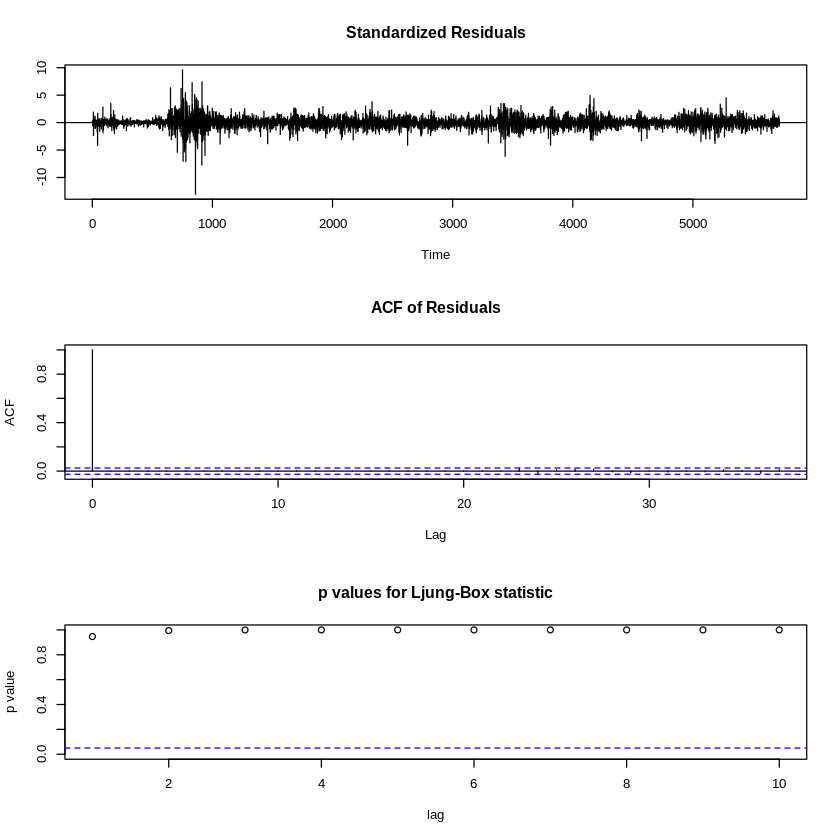

In [ ]:
fit_impro = arima_model_impro
tsdiag(fit_impro)

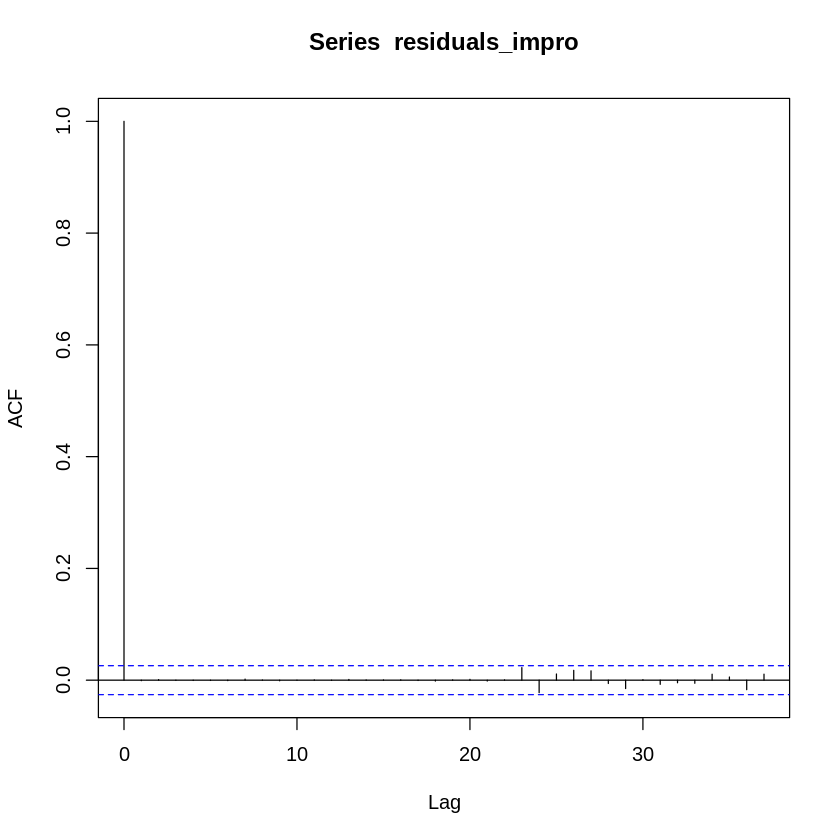

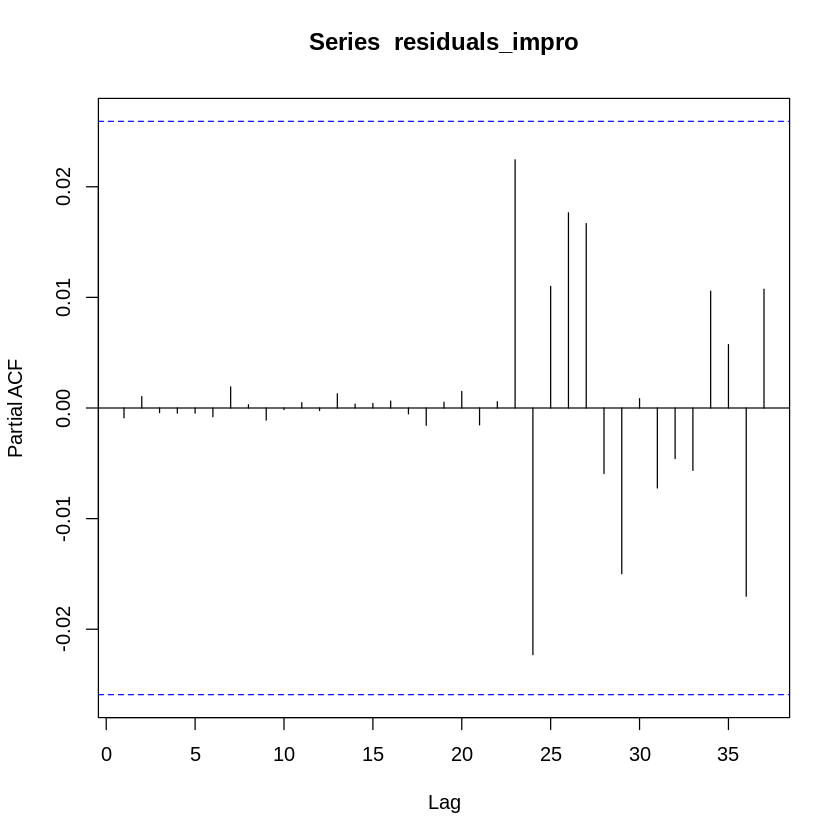

In [ ]:
residuals_impro <- residuals(arima_model_impro)

# Plot ACF of residuals
acf(residuals_impro)

# Plot PACF of residuals
pacf(residuals_impro)

In [ ]:
# Cuts off after lag 22 for SPACF plot -> AR(22)
arima_model_impro1 = arima(ts_data, order = c(22,1,0))
summary(arima_model_impro1)

# AIC value decreased (improved)


Call:
arima(x = ts_data, order = c(22, 1, 0))

Coefficients:
          ar1     ar2     ar3      ar4      ar5      ar6     ar7      ar8
      -0.0004  0.0058  0.0291  -0.0086  -0.0076  -0.0029  0.0062  -0.0163
s.e.   0.0132  0.0132  0.0132   0.0132   0.0132   0.0132  0.0132   0.0132
          ar9    ar10    ar11    ar12    ar13     ar14    ar15     ar16
      -0.0069  0.0424  0.0052  0.0291  0.0223  -0.0038  0.0130  -0.0008
s.e.   0.0132  0.0132  0.0132  0.0132  0.0132   0.0132  0.0132   0.0132
         ar17    ar18    ar19    ar20    ar21     ar22
      -0.0447  0.0101  0.0137  0.0097  0.0037  -0.0391
s.e.   0.0132  0.0132  0.0132  0.0132  0.0132   0.0132

sigma^2 estimated as 2.869e-05:  log likelihood = 21789.09,  aic = -43532.17

Training set error measures:
                        ME        RMSE        MAE          MPE      MAPE
Training set -2.150655e-05 0.005355437 0.00367616 -0.002128386 0.2448924
                 MASE         ACF1
Training set 1.000104 0.0007365007

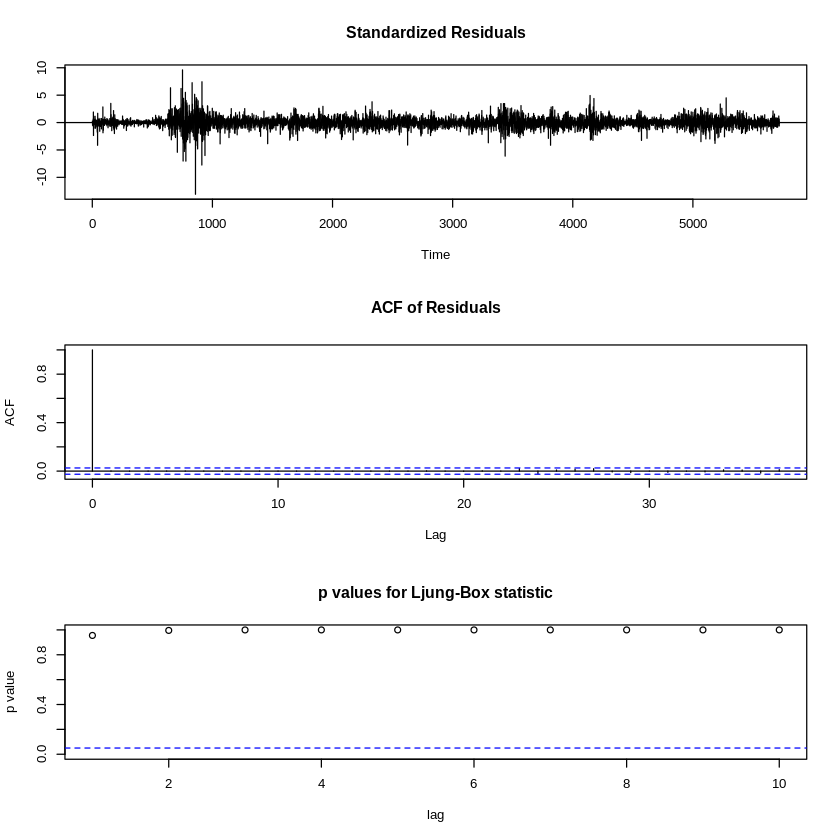

In [ ]:
fit_impro1 = arima_model_impro1
tsdiag(fit_impro1)

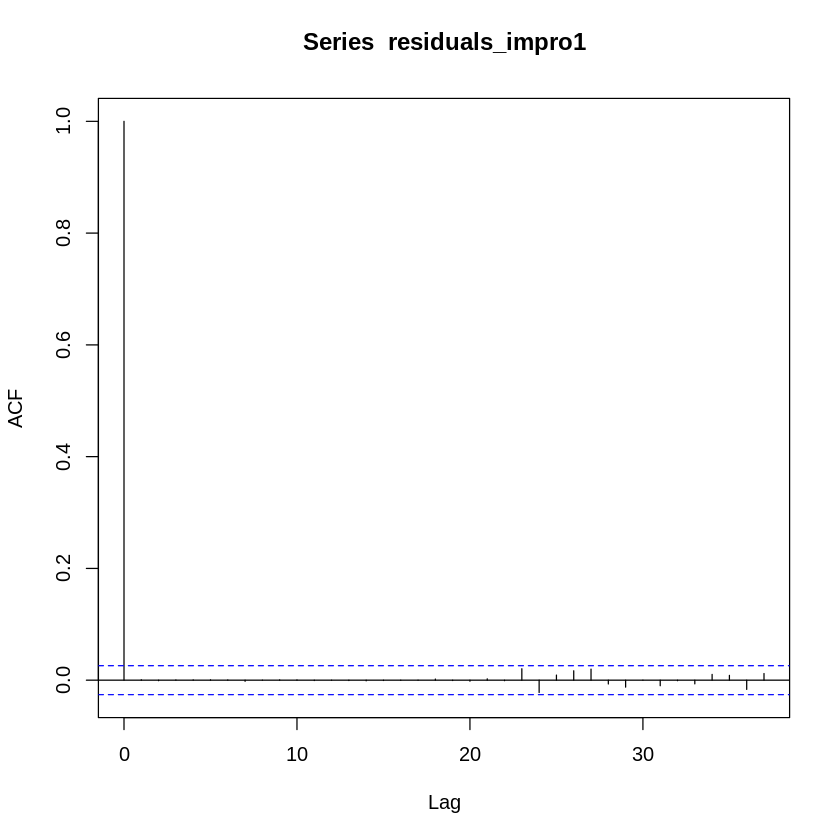

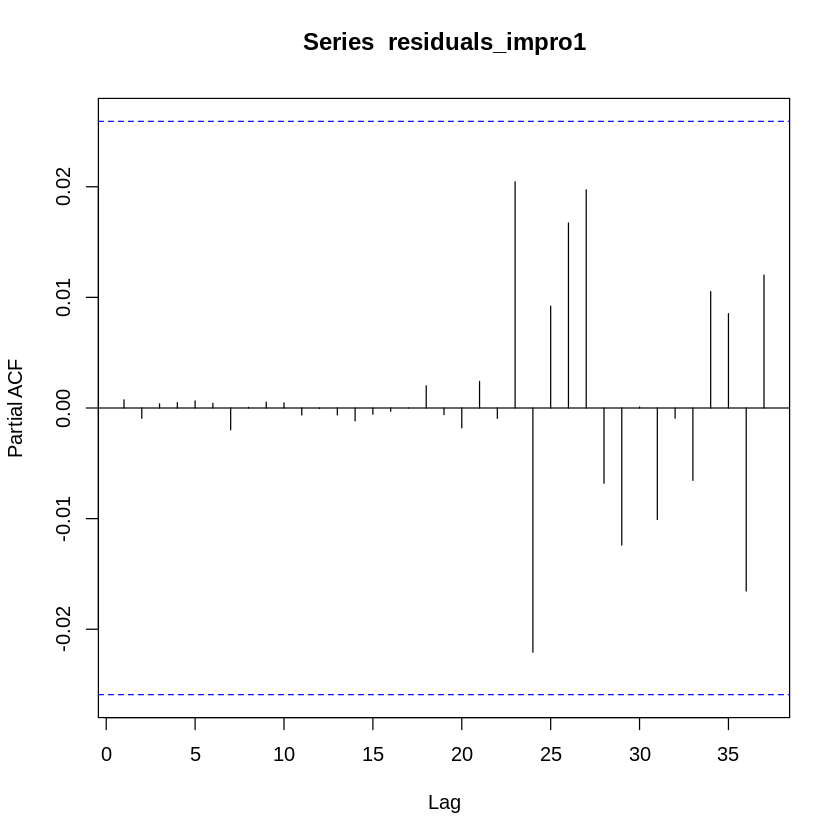

In [ ]:
residuals_impro1 <- residuals(arima_model_impro1)

# Plot ACF of residuals
acf(residuals_impro1)

# Plot PACF of residuals
pacf(residuals_impro1)

In [ ]:
# Cuts off after lag 17 for SACF plot -> MA(17)
arima_model_improA = arima(ts_data, order = c(0,1,17))
summary(arima_model_improA)


Call:
arima(x = ts_data, order = c(0, 1, 17))

Coefficients:
         ma1     ma2     ma3      ma4      ma5      ma6     ma7      ma8
      0.0002  0.0064  0.0288  -0.0086  -0.0089  -0.0013  0.0035  -0.0177
s.e.  0.0132  0.0132  0.0132   0.0132   0.0133   0.0133  0.0133   0.0133
          ma9    ma10    ma11    ma12    ma13     ma14    ma15     ma16
      -0.0047  0.0439  0.0028  0.0306  0.0228  -0.0047  0.0126  -0.0021
s.e.   0.0131  0.0132  0.0138  0.0136  0.0131   0.0134  0.0132   0.0133
         ma17
      -0.0449
s.e.   0.0132

sigma^2 estimated as 2.874e-05:  log likelihood = 21784.05,  aic = -43532.1

Training set error measures:
                        ME        RMSE         MAE          MPE      MAPE
Training set -2.157336e-05 0.005360175 0.003673844 -0.002136795 0.2447233
                  MASE          ACF1
Training set 0.9994738 -0.0005611544

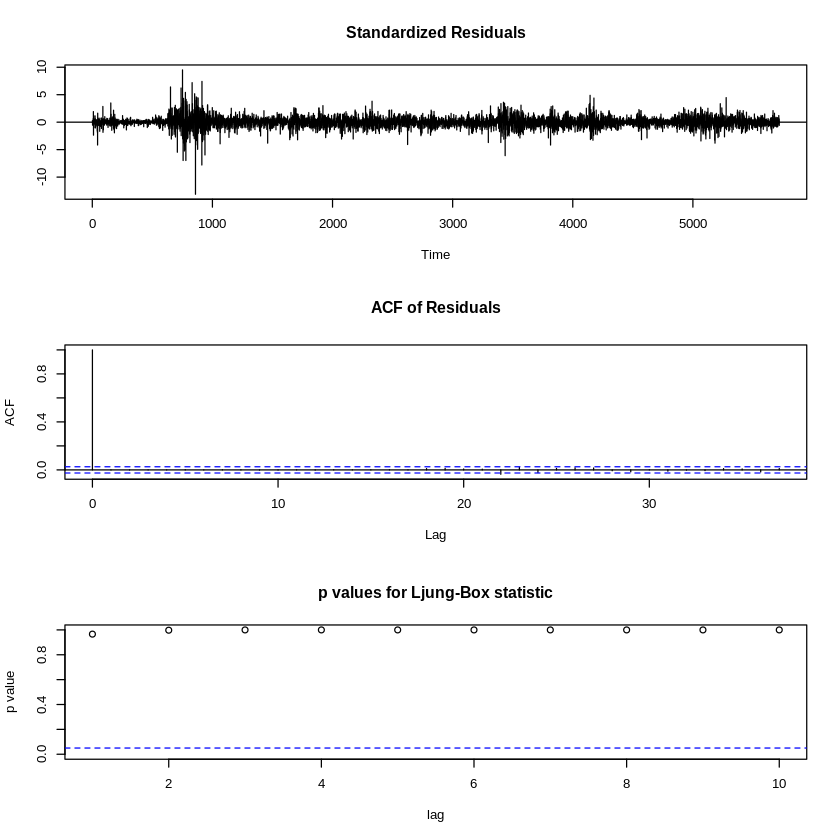

In [ ]:
fit_improA = arima_model_improA
tsdiag(fit_improA)

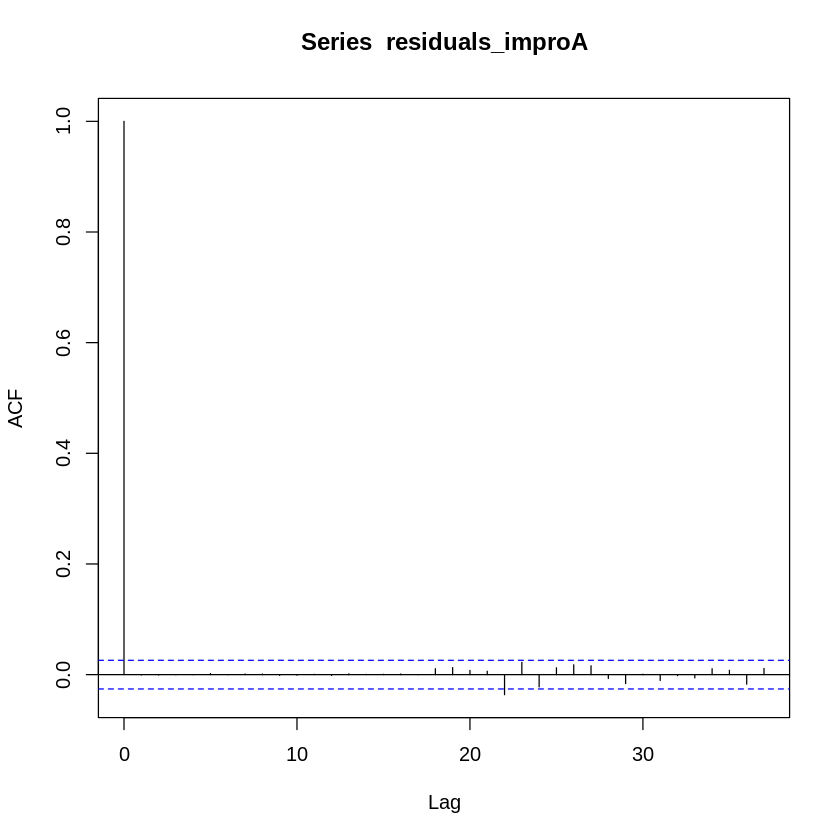

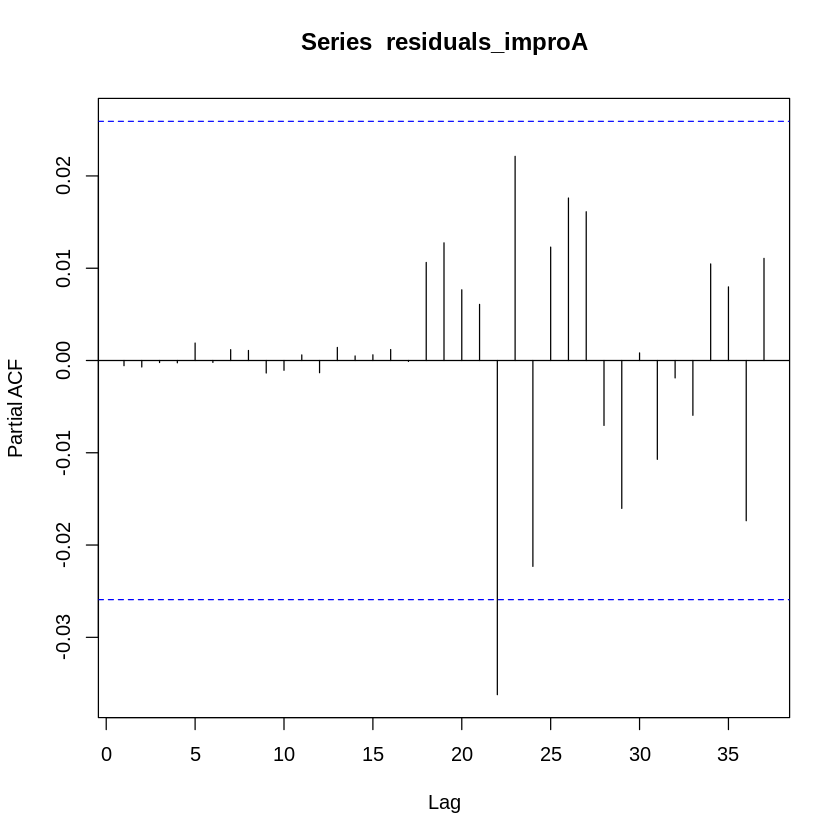

In [ ]:
residuals_improA <- residuals(arima_model_improA)

# Plot ACF of residuals
acf(residuals_improA)

# Plot PACF of residuals
pacf(residuals_improA)

In [ ]:
# Cuts off after lag 17 for SPACF plot -> AR(17)
arima_model_impro2 = arima(ts_data, order = c(17,1,0))
summary(arima_model_impro2)


Call:
arima(x = ts_data, order = c(17, 1, 0))

Coefficients:
          ar1     ar2     ar3      ar4      ar5      ar6     ar7      ar8
      -0.0008  0.0050  0.0283  -0.0091  -0.0055  -0.0023  0.0063  -0.0153
s.e.   0.0132  0.0132  0.0132   0.0132   0.0132   0.0132  0.0132   0.0132
          ar9    ar10    ar11    ar12    ar13     ar14    ar15     ar16
      -0.0072  0.0414  0.0050  0.0274  0.0225  -0.0034  0.0128  -0.0004
s.e.   0.0132  0.0132  0.0132  0.0132  0.0132   0.0132  0.0132   0.0132
         ar17
      -0.0441
s.e.   0.0132

sigma^2 estimated as 2.874e-05:  log likelihood = 21783.63,  aic = -43531.27

Training set error measures:
                        ME        RMSE         MAE          MPE      MAPE
Training set -2.143452e-05 0.005360565 0.003672534 -0.002123164 0.2446315
                  MASE         ACF1
Training set 0.9991175 0.0004351227

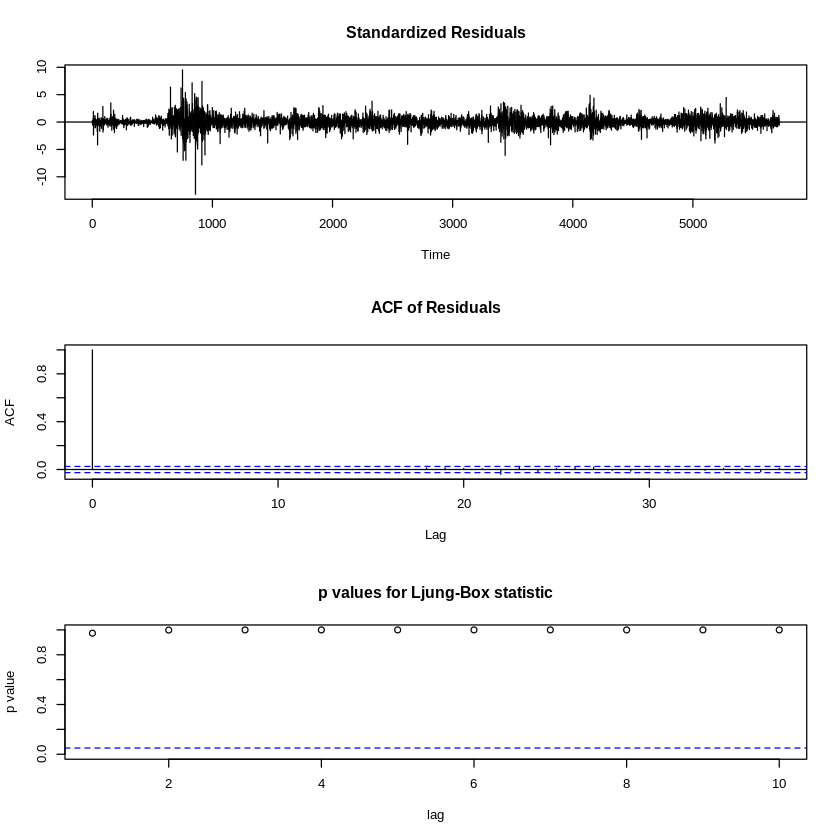

In [ ]:
fit_impro2 = arima_model_impro2
tsdiag(fit_impro2)

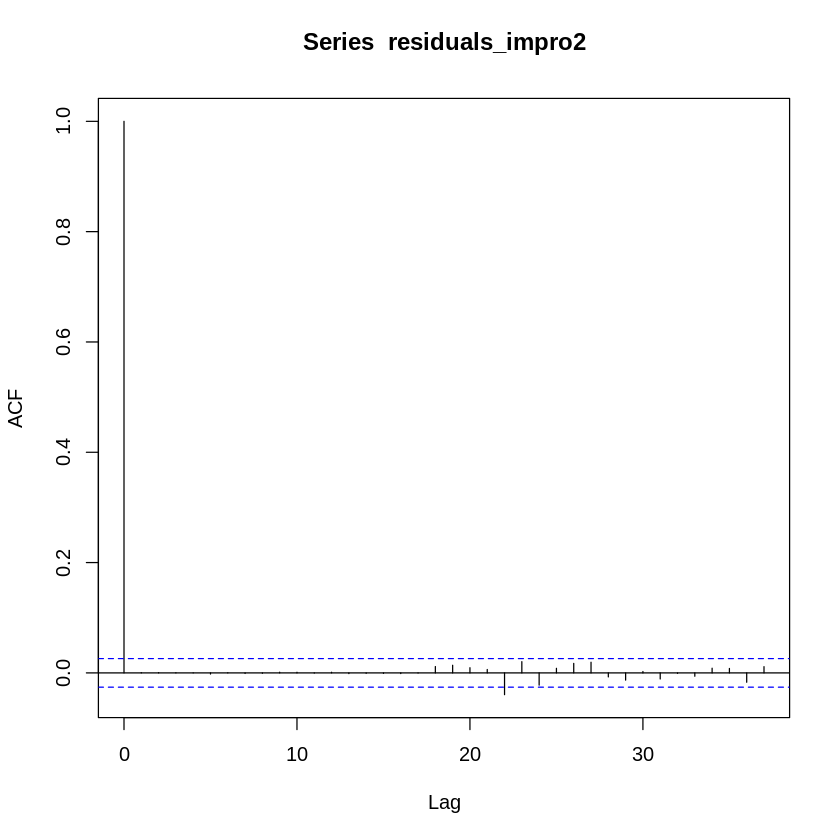

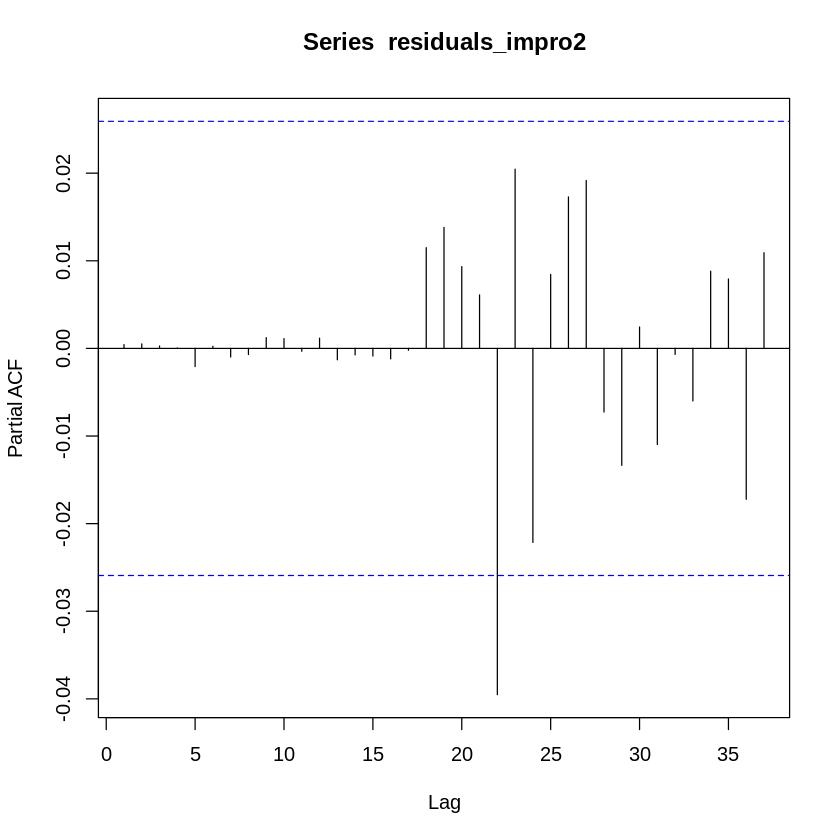

In [ ]:
residuals_impro2 <- residuals(arima_model_impro2)

# Plot ACF of residuals
acf(residuals_impro2)

# Plot PACF of residuals
pacf(residuals_impro2)

In [ ]:
# Cuts off after lag 10 for SPACF plot -> MA(10)
arima_model_impro3 = arima(ts_data, order = c(0,1,10))
summary(arima_model_impro3)


Call:
arima(x = ts_data, order = c(0, 1, 10))

Coefficients:
          ma1     ma2     ma3      ma4      ma5      ma6     ma7      ma8
      -0.0002  0.0036  0.0283  -0.0093  -0.0070  -0.0016  0.0082  -0.0170
s.e.   0.0132  0.0132  0.0132   0.0133   0.0132   0.0128  0.0133   0.0134
          ma9    ma10
      -0.0096  0.0418
s.e.   0.0132  0.0133

sigma^2 estimated as 2.884e-05:  log likelihood = 21773.63,  aic = -43525.27

Training set error measures:
                        ME        RMSE         MAE          MPE      MAPE
Training set -2.206501e-05 0.005369972 0.003673939 -0.002187453 0.2447308
                  MASE         ACF1
Training set 0.9994996 0.0001191939

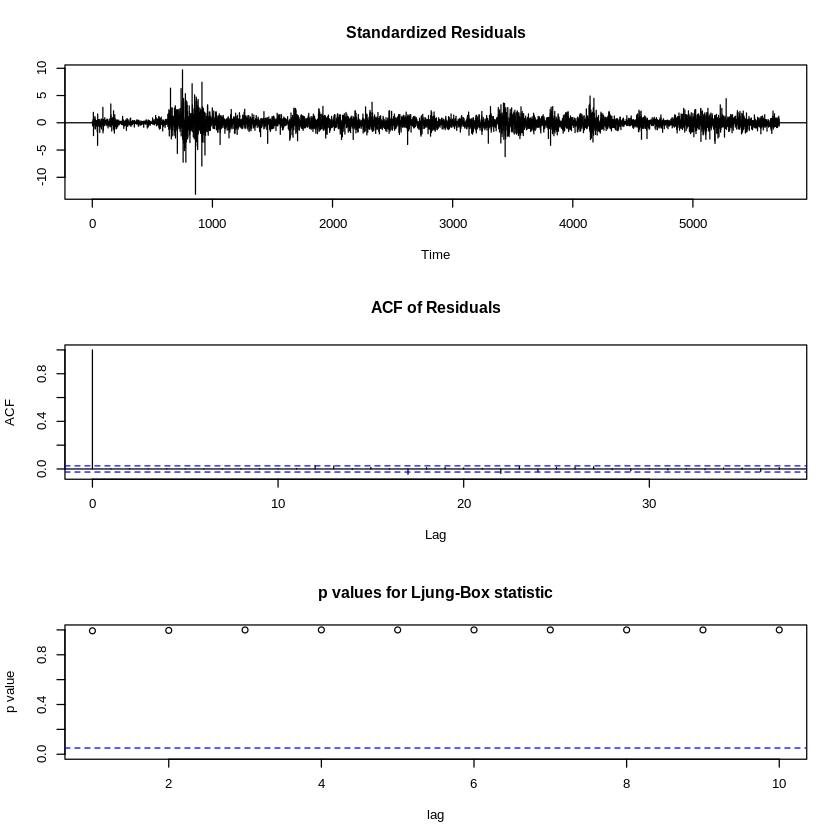

In [ ]:
fit_impro3 = arima_model_impro3
tsdiag(fit_impro3)

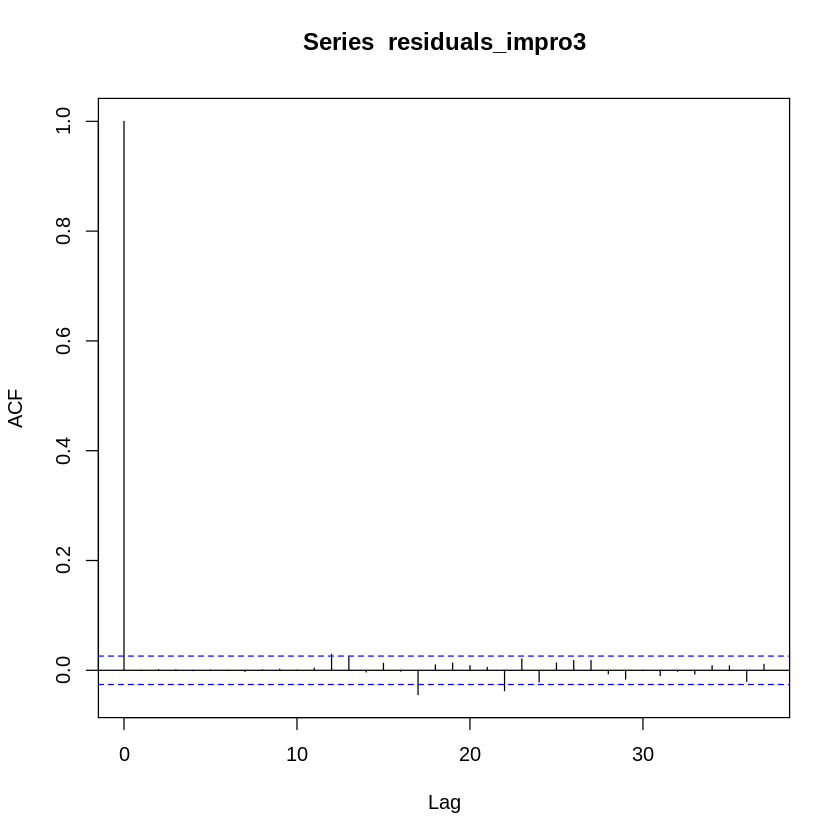

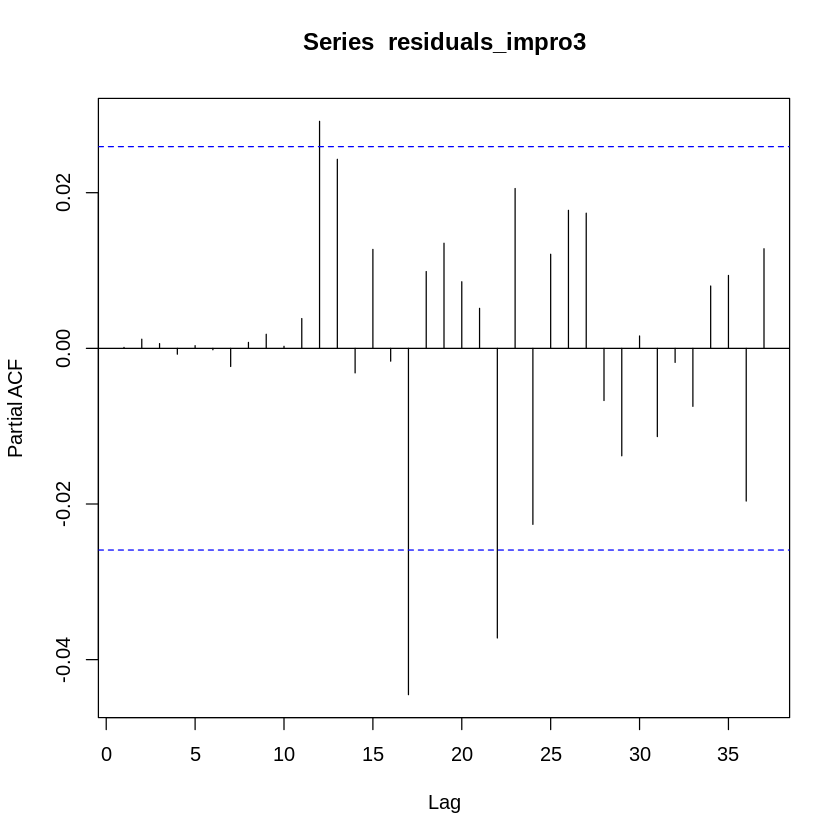

In [ ]:
residuals_impro3 <- residuals(arima_model_impro3)

# Plot ACF of residuals
acf(residuals_impro3)

# Plot PACF of residuals
pacf(residuals_impro3)

Improved model -> ARIMA(0, 1, 22)
arima_model_impro / fit_impro

Forecast

In [ ]:
install.packages(forecast)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



ERROR: Error in as.character(x): cannot coerce type 'closure' to vector of type 'character'


In [ ]:
#Make predictions
library(forecast)
model = arima(ts_data, order=c(0,1,22))
model


Call:
arima(x = ts_data, order = c(0, 1, 22))

Coefficients:
         ma1     ma2     ma3      ma4      ma5      ma6     ma7      ma8
      0.0013  0.0036  0.0298  -0.0074  -0.0063  -0.0009  0.0020  -0.0171
s.e.  0.0132  0.0132  0.0133   0.0133   0.0133   0.0133  0.0133   0.0132
          ma9    ma10    ma11    ma12    ma13     ma14    ma15     ma16
      -0.0054  0.0432  0.0030  0.0299  0.0232  -0.0051  0.0132  -0.0011
s.e.   0.0133  0.0133  0.0133  0.0136  0.0130   0.0134  0.0133   0.0133
         ma17    ma18    ma19    ma20    ma21     ma22
      -0.0446  0.0127  0.0115  0.0049  0.0081  -0.0371
s.e.   0.0131  0.0134  0.0131  0.0132  0.0137   0.0134

sigma^2 estimated as 2.868e-05:  log likelihood = 21789.13,  aic = -43532.26

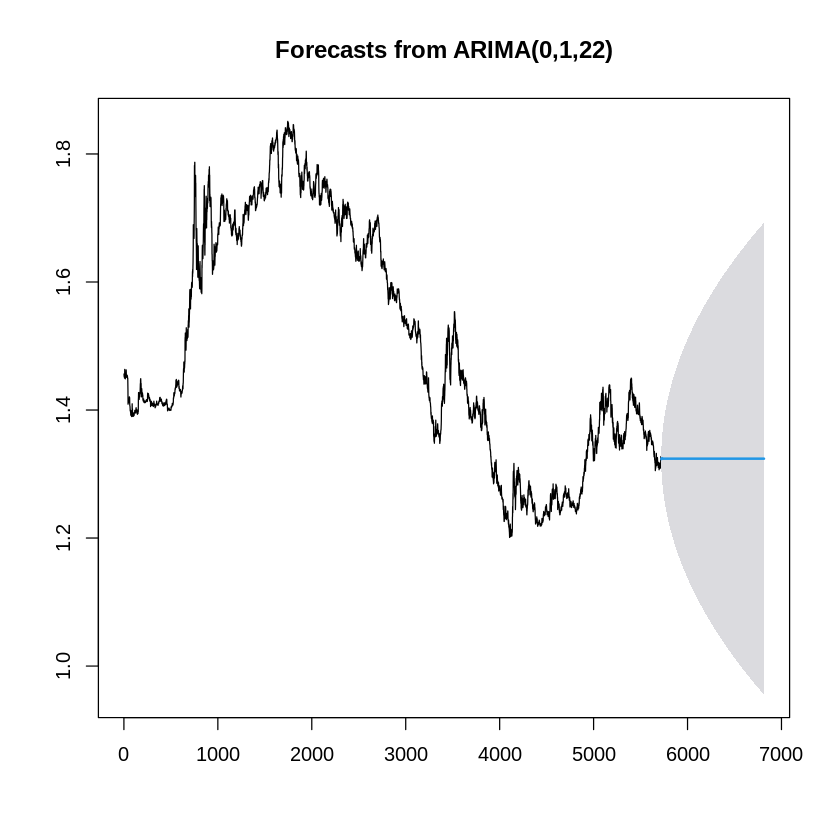

In [ ]:
myforecast <- forecast(model, level=c(95), h=1095)
#print(myforecast)
plot(myforecast)

In [ ]:
# Forecast for the entire length of the original data
forecast_values <- predict(model, n.ahead = 1095)

# Print the forecasts
print(forecast_values)

$pred
Time Series:
Start = 5720 
End = 6814 
Frequency = 1 
   [1] 1.323723 1.323336 1.323349 1.323523 1.323577 1.323600 1.323647 1.324422
   [9] 1.324757 1.324767 1.324625 1.324272 1.324138 1.324223 1.324215 1.324265
  [17] 1.324339 1.324076 1.324015 1.323878 1.323879 1.324002 1.324002 1.324002
  [25] 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002
  [33] 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002
  [41] 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002
  [49] 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002
  [57] 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002
  [65] 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002
  [73] 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002
  [81] 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002
  [89] 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1.324002 1

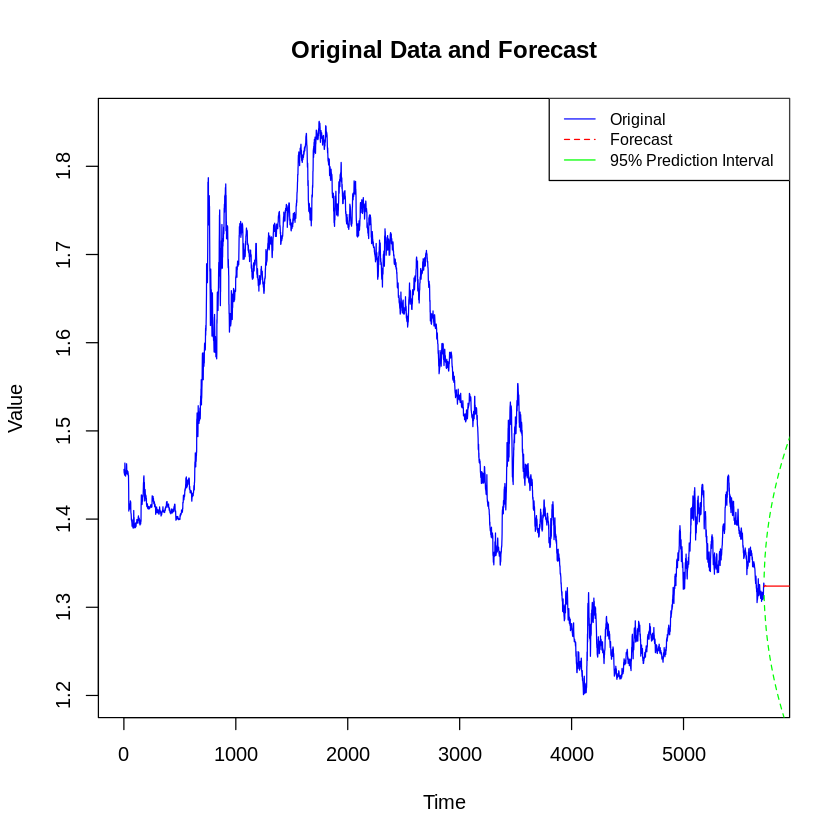

In [ ]:
# Plotting original data
plot(ts_data, main="Original Data and Forecast", xlab="Time", ylab="Value", col="blue")

# Adding forecasted values to the plot
lines(forecast_values$pred, col="red")  # Forecasted values
lines(forecast_values$pred + 1.96 * forecast_values$se, col="green", lty=2)  # Upper bound of prediction interval
lines(forecast_values$pred - 1.96 * forecast_values$se, col="green", lty=2)  # Lower bound of prediction interval

# Adding legend
legend("topright", legend=c("Original", "Forecast", "95% Prediction Interval"), col=c("blue", "red", "green"), lty=1:2, cex=0.8)

     Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
5720       1.323723 1.316859 1.330587 1.313226 1.334220
5721       1.323336 1.313623 1.333049 1.308481 1.338191
5722       1.323349 1.311435 1.335262 1.305129 1.341569
5723       1.323523 1.309653 1.337393 1.302311 1.344736
5724       1.323577 1.308018 1.339137 1.299781 1.347374
5725       1.323600 1.306535 1.340665 1.297501 1.349699
5726       1.323647 1.305201 1.342093 1.295436 1.351858
5727       1.324422 1.304687 1.344158 1.294240 1.354605
5728       1.324757 1.303851 1.345664 1.292784 1.356731
5729       1.324767 1.302764 1.346771 1.291116 1.358419
5730       1.324625 1.301486 1.347764 1.289237 1.360012
5731       1.324272 1.300045 1.348499 1.287220 1.361323
5732       1.324138 1.298811 1.349466 1.285404 1.362873
5733       1.324223 1.297796 1.350650 1.283807 1.364639
5734       1.324215 1.296743 1.351688 1.282199 1.366231
5735       1.324265 1.295760 1.352769 1.280671 1.367858
5736       1.324339 1.294842 1.353837 1.279226 1

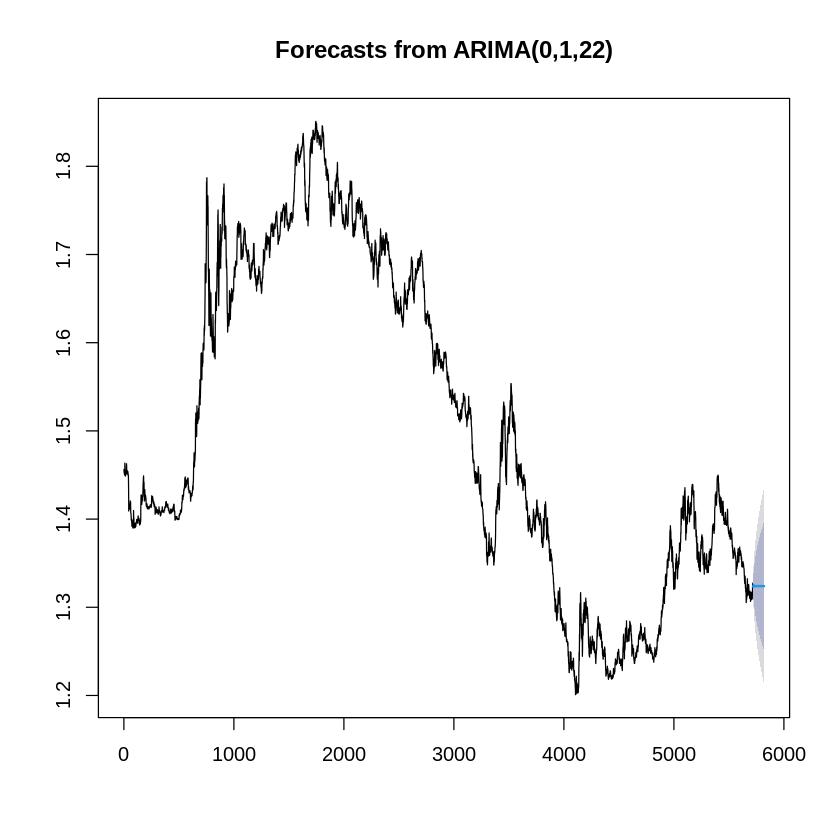

In [ ]:
library(forecast)
forecast_values <- forecast(arima_model_impro, h=100)
print(forecast_values)
plot(forecast_values)

# Output was constant -> Could be due to overfitting
# Output becomes constant once h goes above 20

     Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
5720       1.323750 1.316868 1.330633 1.313224 1.334276
5721       1.323687 1.313954 1.333419 1.308803 1.338571
5722       1.323488 1.311555 1.335421 1.305237 1.341738
5723       1.323494 1.309608 1.337380 1.302257 1.344731
5724       1.323637 1.308070 1.339204 1.299830 1.347445
5725       1.323843 1.306780 1.340907 1.297747 1.349940
5726       1.323853 1.305418 1.342288 1.295659 1.352046
5727       1.324038 1.304307 1.343769 1.293862 1.354214
5728       1.324036 1.303128 1.344944 1.292059 1.356012
5729       1.323906 1.301904 1.345908 1.290257 1.357555
5730       1.323906 1.300776 1.347037 1.288531 1.359281
5731       1.323906 1.299699 1.348113 1.286885 1.360927
5732       1.323906 1.298669 1.349144 1.285309 1.362503
5733       1.323906 1.297679 1.350134 1.283795 1.364018
5734       1.323906 1.296725 1.351088 1.282336 1.365477
5735       1.323906 1.295803 1.352009 1.280926 1.366886
5736       1.323906 1.294911 1.352902 1.279562 1

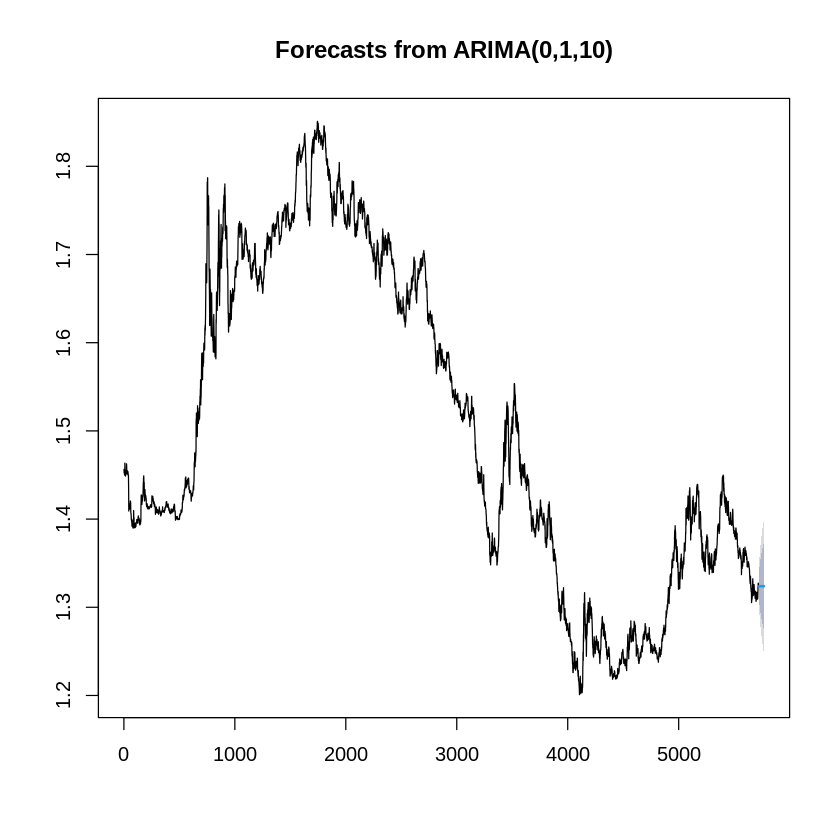

In [ ]:
# Try with smaller MA value to avoid overfitting issue

forecast_values1 <- forecast(arima_model_impro3, h=50)
print(forecast_values1)
plot(forecast_values1)

# Results are worse

     Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
5720       1.323438 1.316591 1.330284 1.312966 1.333909
5721       1.322685 1.313003 1.332366 1.307878 1.337491
5722       1.322715 1.310838 1.334593 1.304550 1.340880
5723       1.322858 1.309032 1.336684 1.301713 1.344003
5724       1.323093 1.307590 1.338595 1.299384 1.346801
5725       1.323339 1.306339 1.340339 1.297340 1.349338
5726       1.323700 1.305332 1.342069 1.295608 1.351793
5727       1.324313 1.304660 1.343966 1.294256 1.354369
5728       1.324454 1.303629 1.345278 1.292605 1.356302
5729       1.325046 1.303125 1.346966 1.291521 1.358571
5730       1.325224 1.302170 1.348278 1.289966 1.360482
5731       1.324814 1.300665 1.348962 1.287882 1.361745
5732       1.324454 1.299200 1.349707 1.285832 1.363076
5733       1.324424 1.298070 1.350778 1.284118 1.364730
5734       1.324466 1.297059 1.351873 1.282551 1.366381
5735       1.324753 1.296309 1.353197 1.281252 1.368254
5736       1.324949 1.295510 1.354388 1.279925 1

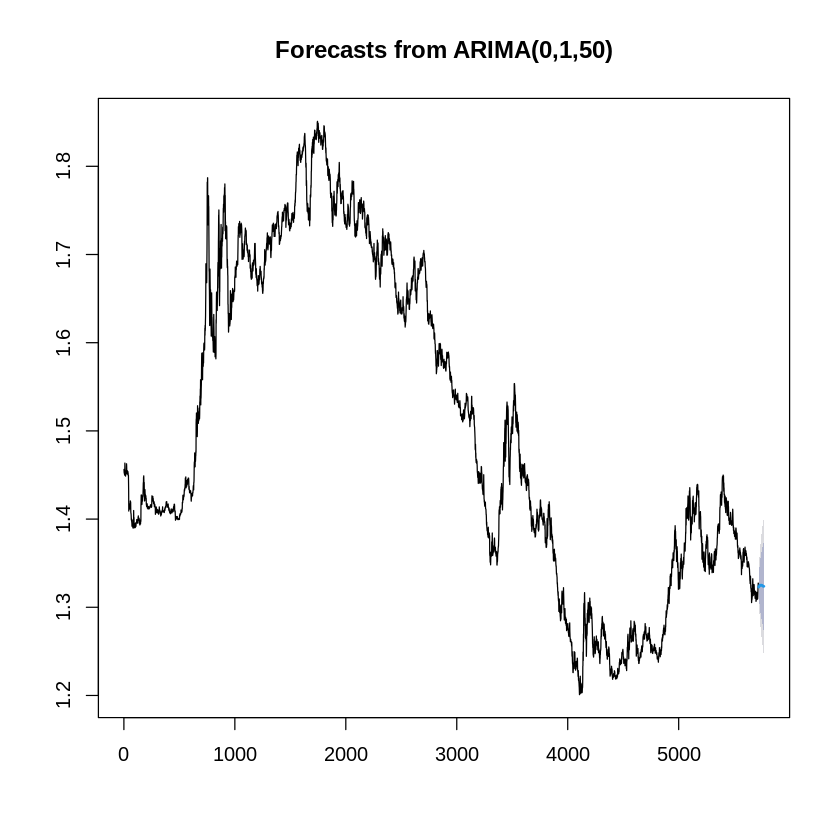

In [ ]:
# Try with larger MA value to avoid overfitting issue
fits = arima(ts_data, order=c(0,1,50))

     Point Forecast    Lo 80    Hi 80     Lo 95    Hi 95
5720       1.323438 1.316591 1.330284 1.3129664 1.333909
5721       1.322685 1.313003 1.332366 1.3078781 1.337491
5722       1.322715 1.310838 1.334593 1.3045504 1.340880
5723       1.322858 1.309032 1.336684 1.3017133 1.344003
5724       1.323093 1.307590 1.338595 1.2993840 1.346801
5725       1.323339 1.306339 1.340339 1.2973398 1.349338
5726       1.323700 1.305332 1.342069 1.2956081 1.351793
5727       1.324313 1.304660 1.343966 1.2942561 1.354369
5728       1.324454 1.303629 1.345278 1.2926055 1.356302
5729       1.325046 1.303125 1.346966 1.2915207 1.358571
5730       1.325224 1.302170 1.348278 1.2899661 1.360482
5731       1.324814 1.300665 1.348962 1.2878821 1.361745
5732       1.324454 1.299200 1.349707 1.2858319 1.363076
5733       1.324424 1.298070 1.350778 1.2841184 1.364730
5734       1.324466 1.297059 1.351873 1.2825509 1.366381
5735       1.324753 1.296309 1.353197 1.2812523 1.368254
5736       1.324949 1.295510 1.

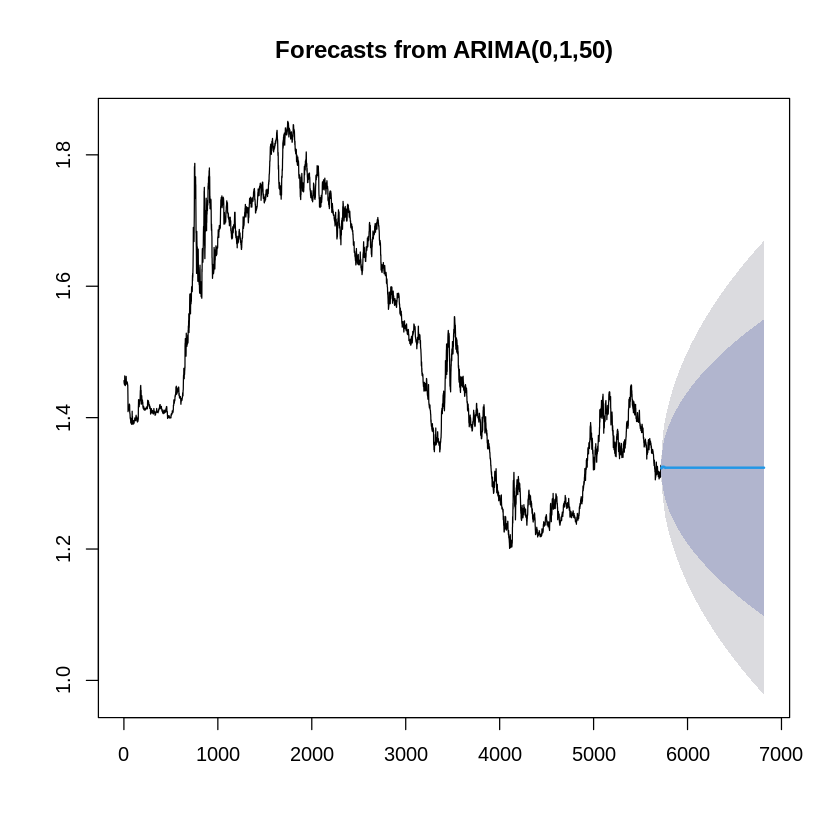

In [ ]:
forecast_values1 <- forecast(fits, h=1095)
print(forecast_values1)
plot(forecast_values1)